# **Tutorial:** Real-time Object Detection with YOLO

In this tutorial, you will learn how to use the YOLOv26 model with OpenCV to automatically detect and draw bounding boxes around objects in an image.

### **Step 1: Install Required Packages**

Install the necessary packages including OpenCV and other dependencies:

In [1]:
%pip install --upgrade ultralytics
%pip install opencv-python
%pip install matplotlib
%pip install numpy==1.26.4 --force-reinstall

   ---------------------------------------- 0.0/1.2 MB ? eta -:--:--
   ---------------------------------------- 1.2/1.2 MB 20.2 MB/s  0:00:00
   ---------------------------------------- 0.0/824.0 kB ? eta -:--:--
   ---------------------------------------- 824.0/824.0 kB 37.5 MB/s  0:00:00
   ---------------------------------------- 0.0/47.0 MB ? eta -:--:--
   -------- ------------------------------- 10.0/47.0 MB 47.8 MB/s eta 0:00:01
   ------------ --------------------------- 14.2/47.0 MB 32.9 MB/s eta 0:00:01
   -------------------- ------------------- 24.6/47.0 MB 40.0 MB/s eta 0:00:01
   --------------------------- ------------ 32.8/47.0 MB 38.6 MB/s eta 0:00:01
   ---------------------------------- ----- 40.4/47.0 MB 37.8 MB/s eta 0:00:01
   ---------------------------------------  46.9/47.0 MB 37.8 MB/s eta 0:00:01
   ---------------------------------------- 47.0/47.0 MB 34.0 MB/s  0:00:01
   ---------------------------------------- 0.0/113.7 MB ? eta -:--:--
   -- -----------

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.


Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
   ---------------------------------------- 0.0/15.8 MB ? eta -:--:--
   ----------------- ---------------------- 7.1/15.8 MB 43.7 MB/s eta 0:00:01
   ---------------------------------------  15.7/15.8 MB 43.1 MB/s eta 0:00:01
   ---------------------------------------- 15.8/15.8 MB 38.3 MB/s  0:00:00
  Attempting uninstall: numpy
    Found existing installation: numpy 2.4.2
    Uninstalling numpy-2.4.2:
      Successfully uninstalled numpy-2.4.2
Note: you may need to restart the kernel to use updated packages.


  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
opencv-python 4.13.0.92 requires numpy>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.


Verify the installations:

In [2]:
%pip show opencv-python ultralytics

Name: opencv-python
Version: 4.13.0.92
Summary: Wrapper package for OpenCV python bindings.
Home-page: https://github.com/opencv/opencv-python
Author: 
Author-email: 
License: Apache 2.0
Location: c:\Users\ASUS VIVOBOOK PRO\anaconda3\envs\Naty\Lib\site-packages
Requires: numpy
Required-by: ultralytics
---
Name: ultralytics
Version: 8.4.24
Summary: Ultralytics YOLO 🚀 for SOTA object detection, multi-object tracking, instance segmentation, pose estimation and image classification.
Home-page: https://ultralytics.com
Author: 
Author-email: Glenn Jocher <glenn.jocher@ultralytics.com>, Jing Qiu <jing.qiu@ultralytics.com>
License: AGPL-3.0
Location: c:\Users\ASUS VIVOBOOK PRO\anaconda3\envs\Naty\Lib\site-packages
Requires: matplotlib, numpy, opencv-python, pillow, polars, psutil, pyyaml, requests, scipy, torch, torchvision, ultralytics-thop
Required-by: 
Note: you may need to restart the kernel to use updated packages.


### **Step 2: Import Required Libraries**

Import the libraries you will use:

In [3]:
import numpy as np
import math
import cv2
from ultralytics import YOLO
from matplotlib import pyplot as plt

Creating new Ultralytics Settings v0.0.6 file  
View Ultralytics Settings with 'yolo settings' or at 'C:\Users\ASUS VIVOBOOK PRO\AppData\Roaming\Ultralytics\settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


### **Step 3: Load the YOLOv26 Model**

Load the pre-trained YOLOv26 model (automatically downloads if not available):

In [5]:
# Load a pretrained YOLO model version 26, nano (n) size
model = YOLO('yolo26n.pt')  # Using nano version for speed, other options: yolov26s.pt (small), yolov26m.pt (medium), yolov26l.pt (large), yolov26x.pt (extra large)

In [6]:
# Show class names the model can detect 
model.names

{0: 'person',
 1: 'bicycle',
 2: 'car',
 3: 'motorcycle',
 4: 'airplane',
 5: 'bus',
 6: 'train',
 7: 'truck',
 8: 'boat',
 9: 'traffic light',
 10: 'fire hydrant',
 11: 'stop sign',
 12: 'parking meter',
 13: 'bench',
 14: 'bird',
 15: 'cat',
 16: 'dog',
 17: 'horse',
 18: 'sheep',
 19: 'cow',
 20: 'elephant',
 21: 'bear',
 22: 'zebra',
 23: 'giraffe',
 24: 'backpack',
 25: 'umbrella',
 26: 'handbag',
 27: 'tie',
 28: 'suitcase',
 29: 'frisbee',
 30: 'skis',
 31: 'snowboard',
 32: 'sports ball',
 33: 'kite',
 34: 'baseball bat',
 35: 'baseball glove',
 36: 'skateboard',
 37: 'surfboard',
 38: 'tennis racket',
 39: 'bottle',
 40: 'wine glass',
 41: 'cup',
 42: 'fork',
 43: 'knife',
 44: 'spoon',
 45: 'bowl',
 46: 'banana',
 47: 'apple',
 48: 'sandwich',
 49: 'orange',
 50: 'broccoli',
 51: 'carrot',
 52: 'hot dog',
 53: 'pizza',
 54: 'donut',
 55: 'cake',
 56: 'chair',
 57: 'couch',
 58: 'potted plant',
 59: 'bed',
 60: 'dining table',
 61: 'toilet',
 62: 'tv',
 63: 'laptop',
 64: 'mou

### **Step 4.1: Run YOLO on an Image**

In [7]:
from ultralytics import YOLO

# Load a pretrained YOLO26n model
model = YOLO("yolo26n.pt")

# Define path to the image file
source = r"semana3\img1.png"

# Run inference on the source
results = model(source, show=True)  # list of Results objects


image 1/1 c:\Users\ASUS VIVOBOOK PRO\Desktop\Nataly\Maestria\Vision por computador\Grupales\semana3\img1.png: 480x640 1 person, 1 cat, 1 dog, 1 sports ball, 207.3ms
Speed: 10.5ms preprocess, 207.3ms inference, 2.9ms postprocess per image at shape (1, 3, 480, 640)


### **Step 4.2: Run YOLO on an Image + save result in working directory + plot with matplotlib**


image 1/1 c:\Users\ASUS VIVOBOOK PRO\Desktop\Nataly\Maestria\Vision por computador\Grupales\semana3\img1.png: 480x640 1 person, 1 cat, 1 dog, 1 sports ball, 56.2ms
Speed: 12.0ms preprocess, 56.2ms inference, 0.4ms postprocess per image at shape (1, 3, 480, 640)
Results saved to C:\Users\ASUS VIVOBOOK PRO\Desktop\Nataly\Maestria\Vision por computador\Grupales\runs\detect\semana3\Resultado_yolo\yolo_results


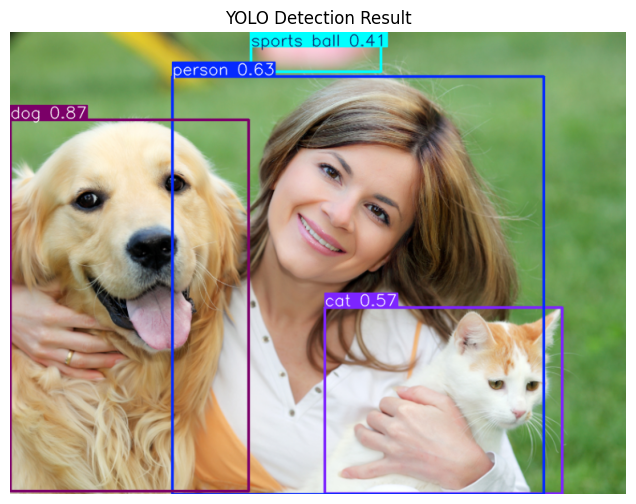

ultralytics.engine.results.Boxes object with attributes:

cls: tensor([16.,  0., 15., 32.])
conf: tensor([0.8740, 0.6274, 0.5723, 0.4056])
data: tensor([[6.1337e-01, 1.0904e+02, 2.9794e+02, 5.7244e+02, 8.7405e-01, 1.6000e+01],
        [2.0294e+02, 5.5634e+01, 6.6507e+02, 5.7600e+02, 6.2745e-01, 0.0000e+00],
        [3.9208e+02, 3.4337e+02, 6.8847e+02, 5.7590e+02, 5.7226e-01, 1.5000e+01],
        [3.0023e+02, 4.4626e-01, 4.6215e+02, 4.9390e+01, 4.0560e-01, 3.2000e+01]])
id: None
is_track: False
orig_shape: (576, 768)
shape: torch.Size([4, 6])
xywh: tensor([[149.2753, 340.7393, 297.3239, 463.4069],
        [434.0077, 315.8168, 462.1285, 520.3665],
        [540.2761, 459.6359, 296.3904, 232.5366],
        [381.1902,  24.9180, 161.9120,  48.9435]])
xywhn: tensor([[0.1944, 0.5916, 0.3871, 0.8045],
        [0.5651, 0.5483, 0.6017, 0.9034],
        [0.7035, 0.7980, 0.3859, 0.4037],
        [0.4963, 0.0433, 0.2108, 0.0850]])
xyxy: tensor([[6.1337e-01, 1.0904e+02, 2.9794e+02, 5.7244e+02],
     

In [9]:
from ultralytics import YOLO
import matplotlib.pyplot as plt
import cv2

# Cargar modelo
model = YOLO("yolo26n.pt")

# Ruta de la imagen
source = r"semana3\img1.png"

# Inferencia + guardar resultado
results = model(
    source, 
    save=True,
    project=r"semana3\Resultado_yolo",  # carpeta base
    name="yolo_results",                # subcarpeta
    exist_ok=True  # sobreescribe si ya existe
    )

# Mostrar con matplotlib
for r in results:
    img = r.plot()  # imagen con bounding boxes
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)  # Convertir BGR a RGB

    plt.figure(figsize=(8, 6))
    plt.imshow(img)
    plt.axis("off")
    plt.title("YOLO Detection Result")
    plt.show()

# (Opcional) imprimir info de detecciones
for r in results:
    print(r.boxes)

### **Step 5.1: Run YOLO on a saved video**

#### Option 1: Save the processed video on the working directory

In [19]:
from ultralytics import YOLO
import cv2
import os

model = YOLO("yolo26n.pt")

source = r"semana3\video.mp4"
output_path = r"semana3\Resultado_yolo\classroom-results.avi"

os.makedirs(os.path.dirname(output_path), exist_ok=True)

results = model(source, stream=True)

out = None

for r in results:
    frame = r.plot()

    if out is None:
        h, w = frame.shape[:2]
        fourcc = cv2.VideoWriter_fourcc(*"MJPG")  # 🔥 estable en Mac
        out = cv2.VideoWriter(output_path, fourcc, 20, (w, h))

        print("Writer abierto:", out.isOpened())

    out.write(frame)

if out:
    out.release()
    print("Video guardado")
else:
    print("Nada se guardó")


video 1/1 (frame 1/186) c:\Users\ASUS VIVOBOOK PRO\Desktop\Nataly\Maestria\Vision por computador\Grupales\semana3\video.mp4: 384x640 1 person, 128.1ms
Writer abierto: True
video 1/1 (frame 2/186) c:\Users\ASUS VIVOBOOK PRO\Desktop\Nataly\Maestria\Vision por computador\Grupales\semana3\video.mp4: 384x640 1 person, 47.7ms
video 1/1 (frame 3/186) c:\Users\ASUS VIVOBOOK PRO\Desktop\Nataly\Maestria\Vision por computador\Grupales\semana3\video.mp4: 384x640 1 person, 1 bird, 56.1ms
video 1/1 (frame 4/186) c:\Users\ASUS VIVOBOOK PRO\Desktop\Nataly\Maestria\Vision por computador\Grupales\semana3\video.mp4: 384x640 1 person, 50.5ms
video 1/1 (frame 5/186) c:\Users\ASUS VIVOBOOK PRO\Desktop\Nataly\Maestria\Vision por computador\Grupales\semana3\video.mp4: 384x640 1 person, 42.2ms
video 1/1 (frame 6/186) c:\Users\ASUS VIVOBOOK PRO\Desktop\Nataly\Maestria\Vision por computador\Grupales\semana3\video.mp4: 384x640 1 person, 44.8ms
video 1/1 (frame 7/186) c:\Users\ASUS VIVOBOOK PRO\Desktop\Nataly\Mae

#### Option 2: Show the video on real-time

In [21]:
from ultralytics import YOLO
import cv2

# Load a pretrained YOLO26n model
model = YOLO("yolo26n.pt")

# Configure your video path
#video_path = "/Users/eugenio/Documents/Computer_Vision/UC.04 Object Detection/Object Detection/fruit-and-vegetable-detection.mp4"
#video_path = "/Users/eugenio/Documents/Computer_Vision/UC.04 Object Detection/Object Detection/car-detection.mp4"
video_path = r"semana3\video.mp4"

# Open video
cap = cv2.VideoCapture(video_path)

# Verify video opened correctly
if not cap.isOpened():
    print("Error: Could not open video. Check the path.")
else:
    print("Video loaded successfully. Press 'q' to exit.")
    
    # Process each video frame
    while True:
        ret, frame = cap.read()
        
        if not ret:
            break  # Finish when video ends
            
        # Run detection with YOLO
        results = model(frame)
        
        # Draw bounding boxes
        for result in results:
            boxes = result.boxes
            for box in boxes:
                x1, y1, x2, y2 = map(int, box.xyxy[0].cpu().numpy())
                confidence = float(box.conf[0].cpu().numpy())
                class_id = int(box.cls[0].cpu().numpy())
                
                # Only show detections with confidence > 50%
                if confidence > 0.5:
                    # Draw rectangle
                    cv2.rectangle(frame, (x1, y1), (x2, y2), (0, 255, 0), 2)
                    
                    # Show label
                    label = f"{model.names[class_id]}: {confidence:.2f}"
                    cv2.putText(frame, label, (x1, y1-10), 
                               cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 255, 0), 2)
        
        # Show frame with detections
        cv2.imshow('Object Detection', frame)
        
        # Exit with 'q' key
        if cv2.waitKey(1) & 0xFF == ord('q'):
            break

# Release resources
cap.release()
cv2.destroyAllWindows()
print("Processing completed.")

Video loaded successfully. Press 'q' to exit.

0: 384x640 1 person, 54.2ms
Speed: 47.4ms preprocess, 54.2ms inference, 0.3ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 1 person, 63.0ms
Speed: 3.0ms preprocess, 63.0ms inference, 0.2ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 1 person, 1 bird, 75.0ms
Speed: 3.2ms preprocess, 75.0ms inference, 0.3ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 1 person, 61.8ms
Speed: 2.7ms preprocess, 61.8ms inference, 0.3ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 1 person, 60.3ms
Speed: 1.7ms preprocess, 60.3ms inference, 0.2ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 1 person, 57.3ms
Speed: 2.2ms preprocess, 57.3ms inference, 0.2ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 1 person, 64.5ms
Speed: 3.6ms preprocess, 64.5ms inference, 0.2ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 1 person, 55.1ms
Speed: 3.7ms preprocess, 55.1ms in

### **Step 5.2: Run YOLO on your webcam video**

#### Option 1: Simple

In [22]:
from ultralytics import YOLO

# Load a pretrained YOLO26n model
model = YOLO("yolo26n.pt")

# Run inference on the source
results = model(source=0, show=True)


1/1: 0... Success  (inf frames of shape 640x480 at 30.00 FPS)

WARNING 
Inference results will accumulate in RAM unless `stream=True` is passed, which can cause out-of-memory errors for large
sources or long-running streams and videos. See https://docs.ultralytics.com/modes/predict/ for help.

Example:
    results = model(source=..., stream=True)  # generator of Results objects
    for r in results:
        boxes = r.boxes  # Boxes object for bbox outputs
        masks = r.masks  # Masks object for segment masks outputs
        probs = r.probs  # Class probabilities for classification outputs

0: 480x640 1 person, 2 beds, 53.3ms
0: 480x640 1 person, 2 beds, 198.4ms
0: 480x640 1 person, 1 chair, 2 beds, 83.4ms
0: 480x640 1 person, 1 chair, 2 beds, 70.9ms
0: 480x640 1 person, 2 beds, 64.9ms
0: 480x640 1 person, 2 beds, 69.4ms
0: 480x640 1 person, 2 beds, 62.1ms
0: 480x640 1 person, 2 beds, 64.3ms
0: 480x640 2 persons, 2 beds, 46.7ms
0: 480x640 1 person, 1 bed, 51.3ms
0: 480x640 1 person

KeyboardInterrupt: 

#### Option 2: Optimized

In [ ]:
from ultralytics import YOLO

# Load a pretrained YOLO26n model
model = YOLO("yolo26n.pt")

#  Run YOLO model on your webcam
results = model.predict(
    source=0, # source=0 uses the default webcam, use source=1 for an external camera.
    show=True, # show=True to display the video feed with detections in a window
    imgsz=256, # resize frames to 256x256 for faster processing and lower resource usage
    vid_stride=6, # process every 3rd frame to reduce CPU/GPU load
    save=False, # do not save the video output (this saves disk space and speeds up processing)
    verbose=False, # stops printing per-frame logs
    conf=0.1, # confidence threshold of 30% (default is 0.25). Adjust as needed.
)

1/1: 0... Success  (inf frames of shape 640x480 at 30.00 FPS)

WARNING 
Inference results will accumulate in RAM unless `stream=True` is passed, which can cause out-of-memory errors for large
sources or long-running streams and videos. See https://docs.ultralytics.com/modes/predict/ for help.

Example:
    results = model(source=..., stream=True)  # generator of Results objects
    for r in results:
        boxes = r.boxes  # Boxes object for bbox outputs
        masks = r.masks  # Masks object for segment masks outputs
        probs = r.probs  # Class probabilities for classification outputs

WARNING Waiting for stream 0
WARNING Waiting for stream 0
WARNING Waiting for stream 0
WARNING Waiting for stream 0
WARNING Waiting for stream 0
WARNING Waiting for stream 0
WARNING Waiting for stream 0
WARNING Waiting for stream 0
WARNING Waiting for stream 0
WARNING Waiting for stream 0
WARNING Waiting for stream 0
WARNING Waiting for stream 0
WARNING Waiting for stream 0
WARNING Waiting for st

KeyboardInterrupt: 

: 

#### Option 3: Complete

In [1]:
from ultralytics import YOLO
import cv2
import math

# Load a pretrained YOLO26n model
model = YOLO("yolo26n.pt")

# Configure video capture from the camera
capture = cv2.VideoCapture(0)  # Open the default camera

# Define class names (YOLO COCO dataset classes)
classNames = ["person", "bicycle", "car", "motorbike", "aeroplane", "bus", "train", "truck", "boat",
              "traffic light", "fire hydrant", "stop sign", "parking meter", "bench", "bird", "cat",
              "dog", "horse", "sheep", "cow", "elephant", "bear", "zebra", "giraffe", "backpack", "umbrella",
              "handbag", "tie", "suitcase", "frisbee", "skis", "snowboard", "sports ball", "kite", "baseball bat",
              "baseball glove", "skateboard", "surfboard", "tennis racket", "bottle", "wine glass", "cup",
              "fork", "knife", "spoon", "bowl", "banana", "apple", "sandwich", "orange", "broccoli",
              "carrot", "hot dog", "pizza", "donut", "cake", "chair", "sofa", "pottedplant", "bed",
              "diningtable", "toilet", "tvmonitor", "laptop", "mouse", "remote", "keyboard", "cell phone",
              "microwave", "oven", "toaster", "sink", "refrigerator", "book", "clock", "vase", "scissors",
              "teddy bear", "hair drier", "toothbrush"]

# Set the image width and height
capture.set(cv2.CAP_PROP_FRAME_WIDTH, 640)  # Image width
capture.set(cv2.CAP_PROP_FRAME_HEIGHT, 480)  # Image height

# Start a loop to process camera frames
while True:
    success, img = capture.read()  # Capture a frame

    # Perform object detection on the captured image (using the pre-trained YOLO model we loaded earlier)
    results = model(img, stream=True)  # Stream generator to process detection results in real time

    # Process the detection results (we can have multiple objects detected in a single frame)
    for r in results:
        boxes = r.boxes

        # Iterate over the detected bounding boxes
        for box in boxes:
            # Get the bounding box coordinates in xyxy format
            x1, y1, x2, y2 = box.xyxy[0]
            x1, y1, x2, y2 = int(x1), int(y1), int(x2), int(y2)  # Convert to integer values

            # Draw the bounding box on the image
            cv2.rectangle(img, (x1, y1), (x2, y2), (255, 0, 255), 1)

            # Get the detection confidence (value between 0 and 1) and round to two decimal places
            confidence = math.ceil((box.conf[0]*100))/100
            print("Confidence --->", confidence)

            # Get the numeric identifier of the detected class name
            cls = int(box.cls[0])
            print("Class name -->", classNames[cls])

            # Display the class name next to the bounding box
            org = [x1, y1]  # Coordinates of the top-left corner for the text
            font = cv2.FONT_HERSHEY_SIMPLEX # Font type
            fontScale = 1  # Font scale
            color = (255, 0, 0)  # Color: Blue (BGR format)
            thickness = 1  # Text line thickness
            cv2.putText(img, classNames[cls], org, font, fontScale, color, thickness)

    # Display the image with a window name and the processed image with detections
    cv2.imshow('YOLO Detection', img)

    # Exit the loop if the 'q' key is pressed
    if cv2.waitKey(10) & 0xFF == ord('q'):
        break

# Release the camera and close all windows
capture.release()
cv2.destroyAllWindows()


0: 480x640 1 person, 2 beds, 161.6ms
Confidence ---> 0.95
Class name --> person
Confidence ---> 0.4
Class name --> bed
Confidence ---> 0.39
Class name --> bed
Speed: 4.0ms preprocess, 161.6ms inference, 0.3ms postprocess per image at shape (1, 3, 480, 640)

0: 480x640 1 person, 1 bed, 94.5ms
Confidence ---> 0.94
Class name --> person
Confidence ---> 0.45
Class name --> bed
Speed: 1.4ms preprocess, 94.5ms inference, 0.3ms postprocess per image at shape (1, 3, 480, 640)

0: 480x640 1 person, 1 bed, 80.8ms
Confidence ---> 0.95
Class name --> person
Confidence ---> 0.36
Class name --> bed
Speed: 1.9ms preprocess, 80.8ms inference, 0.5ms postprocess per image at shape (1, 3, 480, 640)

0: 480x640 1 person, 1 bed, 57.2ms
Confidence ---> 0.94
Class name --> person
Confidence ---> 0.43
Class name --> bed
Speed: 3.1ms preprocess, 57.2ms inference, 0.4ms postprocess per image at shape (1, 3, 480, 640)

0: 480x640 1 person, 1 bed, 58.5ms
Confidence ---> 0.95
Class name --> person
Confidence --->

KeyboardInterrupt: 

___

### **Activity**

In this activity, the work will be developed **locally on your personal computers**.

#### Objective
Design a **specific object detection application** using YOLO (You Only Look Once), focused on **a limited subset of classes**. The system must show that **it only detects the activated classes**, visually ignoring objects belonging to deactivated classes (even if they are present in the image).

#### Instructions

1. **Define a concrete application and the problem it solves**, for example: vehicle detection, fruits detection, etc.
2. **Select between 2 and 4 classes** from the YOLO model to detect.
3. **Modify the model logic** or post-processing so that **only the selected classes are shown**.
4. Run the application on video where **objects from non-activated classes** are also present to demonstrate that the system **ignores those classes**.
5. Show the results clearly, visually indicating the detected and non-detected objects.

#### Deliverable

Must be uploaded to the virtual classroom:

- **Jupyter Notebook in PDF format** containing: 
- Commented code
- Application title and the problem it solves
- List of activated classes
- Screenshots or test images with results showing:
  - Objects *correctly detected* according to the activated classes. At least two objects should be detected at the same time.
  - Objects *not detected* because they belong to deactivated classes (even if present in the image).

### **Grading Rubric**

| **Criteria** | **Points** | **Description** |
|-------------|-----------|----------------|
| **1. Application Definition and Problem Statement** | 4 | Clearly defines a specific object detection application (using only the activated classes) and its practical use case. |
| **2. Implementation** | 2 | Successfully modifies the model logic or post-processing to only show selected classes. Code is functional and properly ignores non-selected classes. The new code added should be commented/documented. |
| **3. Testing & Evidence** | 4 | Provides a clear test showing both detected (activated classes) and ignored (deactivated classes) objects. Evidence demonstrates the |

Total: 10 points

**Sistema de detección de basura para monitoreo domiciliario con alerta automática**

En las zonas residenciales, existen personas que arrojan o dejan basura en lugares no permitidos como fuera de otras casas, esquinas o zonas con áreas verdes, que genera molestias a las personas cercanas a estos lugares aparte del daño ambiental y sanitario, que puede atraer plagas y no da buena imagen al lugar. 

En este caso se plantea que los objetos o clases a detectar sean personas, autos y basura.

In [12]:
# Definir las clases a identificar 
from ultralytics import YOLO
import cv2
import math

# ==============================
# 1. Cargar modelo YOLO
# ==============================
model = YOLO("yolo26n.pt")

# ==============================
# 2. Cargar VIDEO (cambia el nombre)
# ==============================
capture = cv2.VideoCapture(r"semana3\basura2.mp4")  # <-- CAMBIA AQUÍ

# ==============================
# 3. Clases del modelo (COCO)
# ==============================
classNames = ["person", "bicycle", "car", "motorbike", "aeroplane", "bus", "train", "truck", "boat",
              "traffic light", "fire hydrant", "stop sign", "parking meter", "bench", "bird", "cat",
              "dog", "horse", "sheep", "cow", "elephant", "bear", "zebra", "giraffe", "backpack", "umbrella",
              "handbag", "tie", "suitcase", "frisbee", "skis", "snowboard", "sports ball", "kite", "baseball bat",
              "baseball glove", "skateboard", "surfboard", "tennis racket", "bottle", "wine glass", "cup",
              "fork", "knife", "spoon", "bowl", "banana", "apple", "sandwich", "orange", "broccoli",
              "carrot", "hot dog", "pizza", "donut", "cake", "chair", "sofa", "pottedplant", "bed",
              "diningtable", "toilet", "tvmonitor", "laptop", "mouse", "remote", "keyboard", "cell phone",
              "microwave", "oven", "toaster", "sink", "refrigerator", "book", "clock", "vase", "scissors",
              "teddy bear", "hair drier", "toothbrush"]

# ==============================
# 4. Clases ACTIVADAS 
# ==============================
clases_activadas = ["person", "car", "truck", "bus", "backpack", "handbag", "suitcase"]

# Clases basura
clases_basura = ["backpack", "handbag", "suitcase"]

# Historial simple
historial_bolsas = []

# ==============================
# 5. Guardar video de salida (opcional pero recomendado)
# ==============================
width = int(capture.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(capture.get(cv2.CAP_PROP_FRAME_HEIGHT))

out = cv2.VideoWriter(
    r"semana3\Resultado_yolo\resultado.avi",
    cv2.VideoWriter_fourcc(*'mp4v'),
    20,
    (width, height)
)

# ==============================
# 6. Procesar video
# ==============================
while True:
    success, img = capture.read()

    # Terminar cuando el video acabe
    if not success:
        break

    # Detección con YOLO
    results = model(img, stream=True)

    for r in results:
        boxes = r.boxes

        for box in boxes:
            personas = []
            bolsas = []

            # Coordenadas
            x1, y1, x2, y2 = map(int, box.xyxy[0])

            # Confianza
            confidence = math.ceil((box.conf[0] * 100)) / 100

            # Clase detectada
            cls = int(box.cls[0])
            label = classNames[cls]

            # ==============================
            #  FILTRO DE CLASES
            # ==============================
            if label in clases_activadas:

                print(f"Detectado: {label} | Confianza: {confidence}")

                # Colores por clase
                if label == "person":
                    color = (255, 0, 0)  # azul

                elif label in ["car", "truck", "bus"]:
                    color = (0, 255, 255)  # amarillo

                else:  # basura (bolsas)
                    color = (0, 0, 255)  # rojo

                # Dibujar caja
                cv2.rectangle(img, (x1, y1), (x2, y2), color, 2)

                # Texto
                cv2.putText(img, f"{label} {confidence}",
                            (x1, y1 - 10),
                            cv2.FONT_HERSHEY_SIMPLEX,
                            0.7, color, 2)

                # Alerta de basura
                if label in ["backpack", "handbag", "suitcase"]:
                    cv2.putText(img, "POSIBLE BASURA DETECTADA",
                    (50, 50),
                    cv2.FONT_HERSHEY_SIMPLEX,1, (0, 0, 255), 3)

    # Mostrar video
    cv2.imshow("Deteccion YOLO - Filtro de clases", img)

    # Guardar video
    out.write(img)

    # Salir con 'q'
    if cv2.waitKey(10) & 0xFF == ord('q'):
        break

# ==============================
# 7. Liberar recursos
# ==============================
capture.release()
out.release()
cv2.destroyAllWindows()


0: 384x640 (no detections), 64.5ms
Speed: 1.5ms preprocess, 64.5ms inference, 0.2ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 1 person, 103.5ms
Detectado: person | Confianza: 0.29
Speed: 1.6ms preprocess, 103.5ms inference, 0.4ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 (no detections), 88.1ms
Speed: 4.7ms preprocess, 88.1ms inference, 0.2ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 (no detections), 53.4ms
Speed: 1.6ms preprocess, 53.4ms inference, 0.3ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 (no detections), 56.8ms
Speed: 1.8ms preprocess, 56.8ms inference, 0.4ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 (no detections), 60.8ms
Speed: 3.7ms preprocess, 60.8ms inference, 0.3ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 (no detections), 53.5ms
Speed: 1.7ms preprocess, 53.5ms inference, 0.2ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 (no detections), 60.2ms
Sp


0: 384x640 1 person, 1 handbag, 53.3ms
Speed: 44.0ms preprocess, 53.3ms inference, 0.2ms postprocess per image at shape (1, 3, 384, 640)


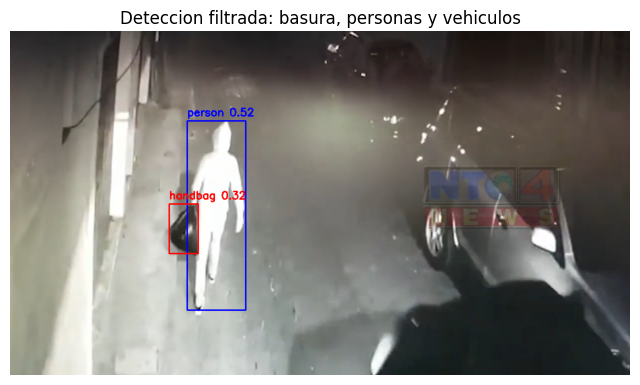

True

In [14]:
from ultralytics import YOLO
import matplotlib.pyplot as plt
import cv2
import math

# ==============================
# 1. Cargar modelo
# ==============================
model = YOLO("yolo26n.pt")

# ==============================
# 2. Ruta de la imagen
# ==============================
source = r"semana3\basura3.jpeg"

# Leer imagen
img = cv2.imread(source)

# ==============================
# 3. Clases
# ==============================
classNames = ["person", "bicycle", "car", "motorbike", "aeroplane", "bus", "train", "truck", "boat",
              "traffic light", "fire hydrant", "stop sign", "parking meter", "bench", "bird", "cat",
              "dog", "horse", "sheep", "cow", "elephant", "bear", "zebra", "giraffe", "backpack", "umbrella",
              "handbag", "tie", "suitcase", "frisbee", "skis", "snowboard", "sports ball", "kite", "baseball bat",
              "baseball glove", "skateboard", "surfboard", "tennis racket", "bottle", "wine glass", "cup",
              "fork", "knife", "spoon", "bowl", "banana", "apple", "sandwich", "orange", "broccoli",
              "carrot", "hot dog", "pizza", "donut", "cake", "chair", "sofa", "pottedplant", "bed",
              "diningtable", "toilet", "tvmonitor", "laptop", "mouse", "remote", "keyboard", "cell phone",
              "microwave", "oven", "toaster", "sink", "refrigerator", "book", "clock", "vase", "scissors",
              "teddy bear", "hair drier", "toothbrush"]

# ==============================
# 4. Clases activadas
# ==============================
clases_activadas = ["person", "car", "truck", "bus",
                    "backpack", "handbag", "suitcase", "bottle", "cup"]

# ==============================
# 5. Detección
# ==============================
results = model(img)

# ==============================
# 6. Dibujar SOLO clases filtradas
# ==============================
for r in results:
    boxes = r.boxes

    for box in boxes:
        x1, y1, x2, y2 = map(int, box.xyxy[0])
        confidence = math.ceil((box.conf[0] * 100)) / 100

        cls = int(box.cls[0])
        label = classNames[cls]

        # FILTRO
        if label in clases_activadas:

            # Colores por tipo
            if label == "person":
                color = (255, 0, 0)
            elif label in ["car", "truck", "bus"]:
                color = (0, 255, 255)
            else:  # basura
                color = (0, 0, 255)

            # Dibujar caja
            cv2.rectangle(img, (x1, y1), (x2, y2), color, 2)

            # Texto
            cv2.putText(img, f"{label} {confidence}",
                        (x1, y1 - 10),
                        cv2.FONT_HERSHEY_SIMPLEX,
                        0.7, color, 2)

# ==============================
# 7. Convertir a RGB para matplotlib
# ==============================
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# ==============================
# 8. Mostrar con matplotlib
# ==============================
plt.figure(figsize=(8, 6))
plt.imshow(img_rgb)
plt.axis("off")
plt.title("Deteccion filtrada: basura, personas y vehiculos")
plt.show()

# ==============================
# 9. Guardar resultado
# ==============================
cv2.imwrite("resultado_filtrado.jpg", img)


0: 384x640 (no detections), 42.6ms
Speed: 33.9ms preprocess, 42.6ms inference, 0.2ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 1 person, 42.4ms
Speed: 1.3ms preprocess, 42.4ms inference, 0.2ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 (no detections), 76.2ms
Speed: 1.2ms preprocess, 76.2ms inference, 0.3ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 (no detections), 58.1ms
Speed: 1.5ms preprocess, 58.1ms inference, 0.2ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 (no detections), 49.0ms
Speed: 1.3ms preprocess, 49.0ms inference, 0.2ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 (no detections), 46.0ms
Speed: 1.7ms preprocess, 46.0ms inference, 0.2ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 (no detections), 49.5ms
Speed: 1.1ms preprocess, 49.5ms inference, 0.2ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 (no detections), 60.1ms
Speed: 1.8ms preprocess, 60.1ms inferen

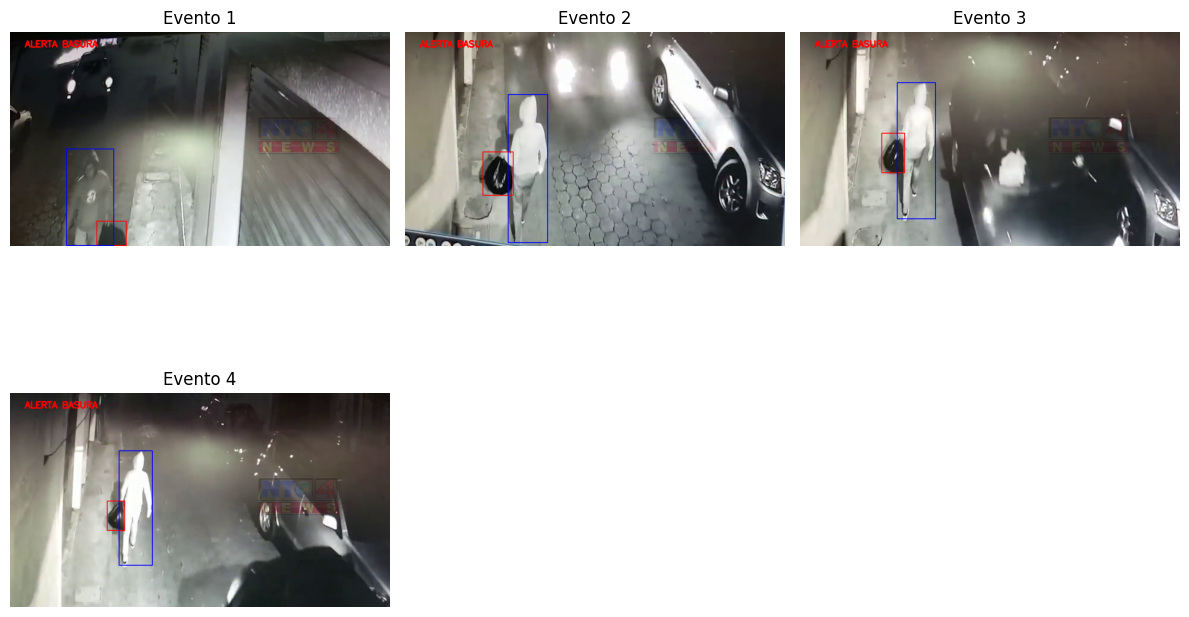

In [23]:
from ultralytics import YOLO
import cv2
import math
import matplotlib.pyplot as plt
import time

# ==============================
# 1. Modelo
# ==============================
model = YOLO("yolo26n.pt")

# ==============================
# 2. Video
# ==============================
capture = cv2.VideoCapture(r"semana3\basura2.mp4")  # CAMBIA AQUÍ

# ==============================
# 3. Clases
# ==============================
classNames = ["person", "bicycle", "car", "motorbike", "aeroplane", "bus", "train", "truck", "boat",
              "traffic light", "fire hydrant", "stop sign", "parking meter", "bench", "bird", "cat",
              "dog", "horse", "sheep", "cow", "elephant", "bear", "zebra", "giraffe", "backpack", "umbrella",
              "handbag", "tie", "suitcase", "frisbee", "skis", "snowboard", "sports ball", "kite", "baseball bat",
              "baseball glove", "skateboard", "surfboard", "tennis racket", "bottle", "wine glass", "cup",
              "fork", "knife", "spoon", "bowl", "banana", "apple", "sandwich", "orange", "broccoli",
              "carrot", "hot dog", "pizza", "donut", "cake", "chair", "sofa", "pottedplant", "bed",
              "diningtable", "toilet", "tvmonitor", "laptop", "mouse", "remote", "keyboard", "cell phone",
              "microwave", "oven", "toaster", "sink", "refrigerator", "book", "clock", "vase", "scissors",
              "teddy bear", "hair drier", "toothbrush"]

# ==============================
# 4. Clases activadas
# ==============================
clases_activadas = ["person", "car", "truck", "bus",
                    "backpack", "handbag", "suitcase", "bottle", "cup"]

clases_basura = ["backpack", "handbag", "suitcase", "bottle", "cup"]

# ==============================
# 5. Lista de eventos
# ==============================
frames_evento = []
ultimo_guardado = 0
max_eventos = 5
# ==============================
# 6. Procesar video
# ==============================
while True:
    success, img = capture.read()
    if not success:
        break

    height, width, _ = img.shape

    results = model(img)

    personas = []
    bolsas = []

    for r in results:
        for box in r.boxes:
            x1, y1, x2, y2 = map(int, box.xyxy[0])
            cls = int(box.cls[0])
            label = classNames[cls]

            if label in clases_activadas:

                if label == "person":
                    personas.append((x1, y1, x2, y2))

                if label in clases_basura:
                    bolsas.append((x1, y1, x2, y2))

    # ==============================
    #  DETECTAR EVENTO
    # ==============================
    for (bx1, by1, bx2, by2) in bolsas:

        for (px1, py1, px2, py2) in personas:

            # Calcular centros
            centro_bolsa = ((bx1 + bx2)//2, (by1 + by2)//2)
            centro_persona = ((px1 + px2)//2, (py1 + py2)//2)

            # Distancia
            distancia = ((centro_bolsa[0] - centro_persona[0])**2 +
                         (centro_bolsa[1] - centro_persona[1])**2)**0.5

            # 🔥 CONDICIÓN
            if distancia < 250 and by2 > height * 0.6:

                if time.time() - ultimo_guardado > 2 and len(frames_evento) < max_eventos:

                    ultimo_guardado = time.time()

                    # Dibujar
                    cv2.rectangle(img, (bx1, by1), (bx2, by2), (0, 0, 255), 2)
                    cv2.rectangle(img, (px1, py1), (px2, py2), (255, 0, 0), 2)

                    cv2.putText(img, "ALERTA BASURA",
                                (50, 50),
                                cv2.FONT_HERSHEY_SIMPLEX,
                                1, (0, 0, 255), 3)

                    frames_evento.append(img.copy())

# ==============================
# 7. Cerrar video
# ==============================
capture.release()

# ==============================
# 8. Mostrar SOLO eventos
# ==============================
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 8))

for i, frame in enumerate(frames_evento):
    frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

    plt.subplot(2, 3, i+1)
    plt.imshow(frame_rgb)
    plt.title(f"Evento {i+1}")
    plt.axis("off")

plt.tight_layout()
plt.show()

Como se puede ver en las imagenes es posible detectar los objetos de interes que en este caso son personas dejando basura fuera de casas en lugares residenciales.

<p style="text-align: right; font-size:14px; color:gray;">
<b>Prepared by:</b><br>
Manuel Eugenio Morocho-Cayamcela
</p>